<a href="https://colab.research.google.com/github/hoin1357/MachineLearning/blob/main/01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

정답데이터 시작일: 2025-05-01
MAE  : 3022.03
RMSE : 4558.66
MAPE : 127.72%
R²   : 0.7384

정답데이터 예측 결과 일부 미리보기
        날짜  실제방문객수  예측방문객수  절대오차    오차율
2025-05-01    2771   10746  7975 287.80
2025-05-02   11903    5730  6173  51.86
2025-05-03    7295   15210  7915 108.50
2025-05-04   33907   20271 13636  40.22
2025-05-05   38060   31053  7007  18.41
2025-05-06   19169   29461 10292  53.69
2025-05-07    3343    2711   632  18.91
2025-05-08    3929    5091  1162  29.57
2025-05-09    2623    5621  2998 114.30
2025-05-10    2241   11832  9591 427.98
2025-05-11   18767   11085  7682  40.93
2025-05-12    4439    2224  2215  49.90
2025-05-13    6041    5572   469   7.76
2025-05-14    6523    3871  2652  40.66
2025-05-15    2865    5559  2694  94.03
2025-05-16    3108    3521   413  13.29
2025-05-17   19980   10786  9194  46.02
2025-05-18   23568   15707  7861  33.35
2025-05-19    3103    6001  2898  93.39
2025-05-20    4586    6537  1951  42.54


/tmp/ipykernel_1092/1482746769.py:305: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/1482746769.py:305: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/1482746769.py:305: UserWarning: Glyph 44061 (\N{HANGUL SYLLABLE GAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/1482746769.py:305: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/1482746769.py:305: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/1482746769.py:305: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/1482746769.py:305: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.

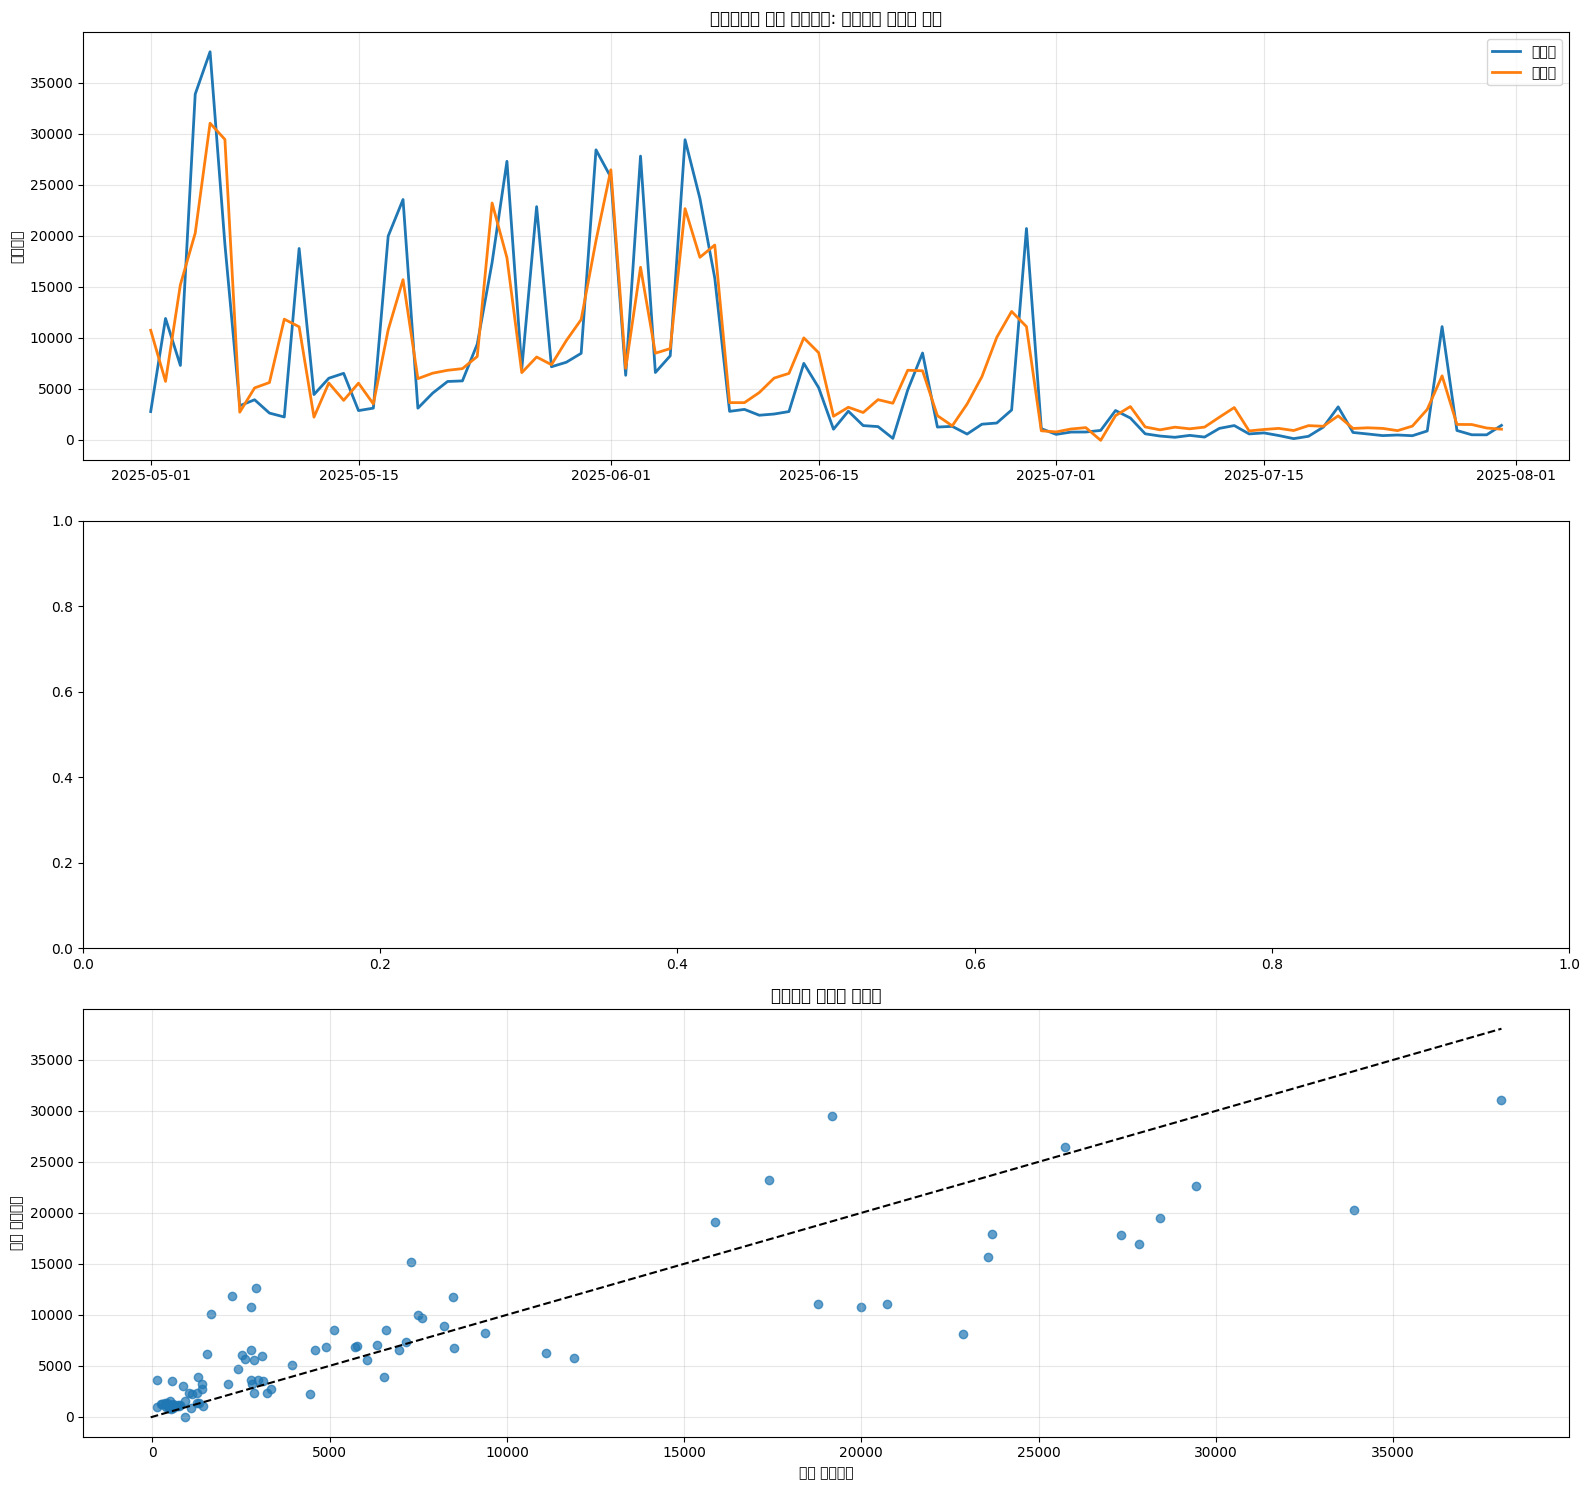


조회 날짜: 2025-05-05
        날짜  실제방문객수  예측방문객수  절대오차   오차율
2025-05-05   38060   31053  7007 18.41


In [3]:


import subprocess
import sys
from pathlib import Path


def install_packages() -> None:

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "holidays"])
    if sys.platform.startswith("linux"):
        subprocess.run(["apt-get", "update", "-y"], check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        subprocess.run(
            ["apt-get", "install", "-y", "fonts-nanum"],
            check=False,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        subprocess.run(["fc-cache", "-fv"], check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)


install_packages()

import holidays
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def set_korean_font() -> None:
    preferred_fonts = ["NanumGothic", "Malgun Gothic", "AppleGothic"]
    available_fonts = {font.name for font in fm.fontManager.ttflist}

    for font_name in preferred_fonts:
        if font_name in available_fonts:
            plt.rcParams["font.family"] = font_name
            break
    plt.rcParams["axes.unicode_minus"] = False


set_korean_font()



# 1. 데이터 파일 이름 설정

데이터파일이름 = "서울대공원_일별_방문객수_전체데이터.csv"



# 2. 데이터 읽기
# 정제된 데이터는 년, 월, 일, 방문객수 4개 열로 되어 있습니다.
# 먼저 년-월-일을 합쳐서 실제 날짜 열을 만듭니다.
데이터 = pd.read_csv(데이터파일이름)
날짜조합용데이터 = 데이터[["년", "월", "일"]].rename(columns={"년": "year", "월": "month", "일": "day"})
데이터["날짜"] = pd.to_datetime(날짜조합용데이터)
데이터 = 데이터.sort_values("날짜").reset_index(drop=True)



# 3. 최신 3개월을 정답데이터로 분리할 기준 날짜 만들기

고유월목록 = 데이터["날짜"].dt.to_period("M").drop_duplicates().sort_values()
정답시작일 = 고유월목록.iloc[-3].to_timestamp()



# 4. 방문객수 결측치 평균 대체

# 방문객수가 비어 있으면 먼저 같은 연-월 평균으로 채웁니다.
# 그래도 비어 있으면 학습 구간 평균으로 채웁니다.
학습구간마스크 = 데이터["날짜"] < 정답시작일
#학습구간 평균을 구함
학습구간평균 = 데이터.loc[학습구간마스크, "방문객수"].dropna().mean()
#연월평균을 구함
연월평균 = 데이터.groupby(데이터["날짜"].dt.to_period("M"))["방문객수"].transform("mean")
#결측치에 연월평균 넣기
데이터["방문객수"] = 데이터["방문객수"].fillna(연월평균)
데이터["방문객수"] = 데이터["방문객수"].fillna(학습구간평균)
데이터["방문객수"] = 데이터["방문객수"].round().astype(int)



# 5. 날짜 기반 특징 만들기

# 모델이 요일, 월, 계절성, 공휴일 효과를 이해할 수 있게
# 날짜에서 여러 숫자 특징을 파생합니다.
데이터["요일번호"] = 데이터["날짜"].dt.dayofweek
데이터["주말여부"] = (데이터["요일번호"] >= 5).astype(int)
데이터["분기"] = 데이터["날짜"].dt.quarter
데이터["연중일수"] = 데이터["날짜"].dt.dayofyear
데이터["연중주차"] = 데이터["날짜"].dt.isocalendar().week.astype(int)
데이터["시작후경과일"] = (데이터["날짜"] - 데이터["날짜"].min()).dt.days
데이터["월_sin"] = np.sin(2 * np.pi * 데이터["월"] / 12)
데이터["월_cos"] = np.cos(2 * np.pi * 데이터["월"] / 12)
데이터["연중일수_sin"] = np.sin(2 * np.pi * 데이터["연중일수"] / 365.25)
데이터["연중일수_cos"] = np.cos(2 * np.pi * 데이터["연중일수"] / 365.25)

# 한국 공휴일 여부를 추가해서, 어린이날이나 연휴 효과를 반영합니다.
연도범위 = range(int(데이터["년"].min()), int(데이터["년"].max()) + 1)
한국공휴일 = holidays.country_holidays("KR", years=연도범위)
데이터["공휴일여부"] = 데이터["날짜"].dt.date.map(lambda 현재날짜: int(현재날짜 in 한국공휴일))



# 6. 과거 방문객수 기반 특징 만들기

# lag_1은 전날 방문객수, lag_7은 7일 전 방문객수입니다.
# rolling_mean_7은 최근 7일 평균 방문객수입니다.

for 시차 in [1, 7, 14, 28]:
    데이터[f"지연값_{시차}"] = 데이터["방문객수"].shift(시차)

# 전년 비슷한 시점의 방문객수는 강한 계절성을 잡는 데 도움이 됩니다.
for 시차 in [364, 365, 371]:
    데이터[f"전년지연값_{시차}"] = 데이터["방문객수"].shift(시차)
#최근 이동평균, 이동편차
이전값 = 데이터["방문객수"].shift(1)
for 기간 in [7, 14, 28]:
    데이터[f"이동평균_{기간}"] = 이전값.rolling(window=기간).mean()
    데이터[f"이동표준편차_{기간}"] = 이전값.rolling(window=기간).std()


# ------------------------------------------------------------
# 7. 학습용 입력(X)과 정답(y) 만들기
# ------------------------------------------------------------
특징열목록 = [
    "년",
    "월",
    "일",
    "요일번호",
    "주말여부",
    "분기",
    "연중일수",
    "연중주차",
    "시작후경과일",
    "월_sin",
    "월_cos",
    "연중일수_sin",
    "연중일수_cos",
    "공휴일여부",
    "지연값_1",
    "지연값_7",
    "지연값_14",
    "지연값_28",
    "전년지연값_364",
    "전년지연값_365",
    "전년지연값_371",
    "이동평균_7",
    "이동평균_14",
    "이동평균_28",
    "이동표준편차_7",
    "이동표준편차_14",
    "이동표준편차_28",
]
#학습 데이터와 정답 데이터 분리
학습마스크 = 데이터["날짜"] < 정답시작일
정답마스크 = 데이터["날짜"] >= 정답시작일
#학습변수들 가져오기
학습입력 = 데이터.loc[학습마스크, 특징열목록]
학습정답 = 데이터.loc[학습마스크, "방문객수"]
#정답 데이터 가져오기
정답입력 = 데이터.loc[정답마스크, 특징열목록]
정답실제값 = 데이터.loc[정답마스크, "방문객수"]


# ------------------------------------------------------------
# 8. 특징 결측치 평균 대체
# ------------------------------------------------------------
# 초반 날짜는 지연값과 이동평균이 비어 있을 수 있습니다.
# 이 값들은 학습 데이터 평균으로만 채워서 데이터 누수를 막습니다.
평균대체기 = SimpleImputer(strategy="mean")
학습입력_대체완료 = pd.DataFrame(
    평균대체기.fit_transform(학습입력),
    columns=특징열목록,
    index=학습입력.index,
)
정답입력_대체완료 = pd.DataFrame(
    평균대체기.transform(정답입력),
    columns=특징열목록,
    index=정답입력.index,
)


# ------------------------------------------------------------
# 9. 모델 만들기
# ------------------------------------------------------------
# HistGradientBoostingRegressor를 선택한 이유
# 1. 방문객수처럼 비선형 패턴이 강한 표 데이터에 잘 맞습니다.
# 2. 요일, 계절성, 공휴일, 최근 추세가 섞여도 성능이 좋습니다.
# 3. 스케일링 없이도 안정적으로 학습됩니다.
모델 = HistGradientBoostingRegressor(
    loss="squared_error",
    #손실함수 - 오차를 제곱해서 양수로 만들어 비교, 큰 오차는 더 커짐
    learning_rate=0.05,
    #트리 수정수치
    max_depth=6,
    #한 트리 안에서 분기점의 횟수를 6으로 제한
    max_iter=500,
    #이전 트리의 결과물을 고치는 과정의 횟수
    min_samples_leaf=10,
    #최종 결과물 개수를 10개로 만들어 과적합 방지
    l2_regularization=0.1,
    #과적합 방지 수식
    random_state=42,
    #랜덤값을 고정하여 학습 결과를 비교 할 수 있게 함
)


# ------------------------------------------------------------
# 10. 모델 학습
# ------------------------------------------------------------
모델.fit(학습입력_대체완료, 학습정답)


# ------------------------------------------------------------
# 11. 정답데이터 예측
# ------------------------------------------------------------
예측값 = 모델.predict(정답입력_대체완료)
예측값_반올림 = np.round(예측값).astype(int)


# ------------------------------------------------------------
# 12. 평가 지표 계산
# ------------------------------------------------------------
# MAE  : 오차값들을 제곱해서 평균을 구함
# RMSE : 오차를 제곱하기 떄문에 큰 오차가 더 커짐
# MAPE : 실제값 대비 몇 퍼센트 정도 틀렸는지
# R²   : 모델의 전체 데이터 이해도
MAE = mean_absolute_error(정답실제값, 예측값_반올림)
RMSE = np.sqrt(mean_squared_error(정답실제값, 예측값_반올림))
MAPE = np.mean(np.where(정답실제값 != 0, np.abs((정답실제값 - 예측값_반올림) / 정답실제값) * 100, 0))
R2 = r2_score(정답실제값, 예측값_반올림)

print(f"정답데이터 시작일: {정답시작일.strftime('%Y-%m-%d')}")
print(f"MAE  : {MAE:.2f}")
print(f"RMSE : {RMSE:.2f}")
print(f"MAPE : {MAPE:.2f}%")
print(f"R²   : {R2:.4f}")


# ------------------------------------------------------------
# 13. 실제값과 예측값 비교표 만들기
# ------------------------------------------------------------
결과표 = 데이터.loc[정답마스크, ["날짜", "방문객수"]].copy()
결과표 = 결과표.rename(columns={"방문객수": "실제방문객수"})
결과표["예측방문객수"] = 예측값_반올림
결과표["절대오차"] = (결과표["실제방문객수"] - 결과표["예측방문객수"]).abs()
결과표["오차율"] = np.where(
    결과표["실제방문객수"] != 0,
    (결과표["절대오차"] / 결과표["실제방문객수"] * 100).round(2),
    0.0,
)

print("\n정답데이터 예측 결과 일부 미리보기")
print(결과표.head(20).to_string(index=False))


# ------------------------------------------------------------
# 14. 시각화
# ------------------------------------------------------------
# 첫 번째 그래프: 날짜별 실제값과 예측값 비교
# 두 번째 그래프: 날짜별 절대 오차
# 세 번째 그래프: 실제값과 예측값 산점도
그림, 축목록 = plt.subplots(3, 1, figsize=(16, 15))

축목록[0].plot(결과표["날짜"], 결과표["실제방문객수"], label="실제값", linewidth=2)
축목록[0].plot(결과표["날짜"], 결과표["예측방문객수"], label="예측값", linewidth=2)
축목록[0].set_title("서울대공원 일별 방문객수: 실제값과 예측값 비교")
축목록[0].set_ylabel("방문객수")
축목록[0].legend()
축목록[0].grid(alpha=0.3)

plt.tight_layout()

try:
    # 코랩 노트북 안에서는 그래프를 바로 화면에 표시합니다.
    try:
        from IPython import get_ipython
    except ModuleNotFoundError:
        get_ipython = None

    if get_ipython is not None and get_ipython() is not None:
        plt.show()
    else:
        미리보기이미지경로 = Path("서울대공원_코랩_그래프_미리보기.png")
        plt.savefig(미리보기이미지경로, dpi=200, bbox_inches="tight")
        print(f"\n그래프 이미지를 저장했습니다: {미리보기이미지경로}")
finally:
    plt.close(그림)
